In [ ]:
import sys
import os
sys.path.insert(0, os.path.abspath('../..'))
import random

import geopandas as gpd
from matplotlib import pyplot as plt 
import numpy as np
import shapely
from shapely.plotting import plot_polygon
import rasterio
import torch

from src.construct_dataset.assign_tile_and_tilegroup import create_tiles


try:
    RANDOM_SEED = int(os.environ["RANDOM_SEED"])
except:
    RANDOM_SEED = 42

from PIL import ImageColor


random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed_all(RANDOM_SEED)
N_GROUPS = 5
parent_rng = np.random.default_rng(seed=RANDOM_SEED)
def get_new_random_seed():
    return parent_rng.integers(0,2**32)


In [2]:
gdf = gpd.GeoDataFrame.from_file("data/gpkgs/bda_2024_patches_2024_classified.gpkg",driver="pyogrio", use_arrow=True).to_crs("EPSG:3857")

/usr/lib/python3.12/contextlib.py:137: RuntimeWarning: driver GPKG does not support open option DRIVER
  return next(self.gen)


In [3]:
tiles = create_tiles(gdf, rows=6, cols=6, buffer_pct=0.1)

value_counts = gdf["tile"].value_counts()
if -1 in value_counts.index:
        value_counts = value_counts.drop(index=[-1])
mean_count = value_counts.mean()
threshold = 0#0.05 * mean_count
keep_tiles = list(value_counts[value_counts > threshold].index.values)


In [4]:
tile_groups = {}

child_rng = np.random.default_rng(get_new_random_seed())
child_rng.shuffle(keep_tiles)
groups = {
    i: keep_tiles[int((i * (len(keep_tiles)/ N_GROUPS))): int(((i+1) * (len(keep_tiles )/ N_GROUPS)))]for i in range(N_GROUPS)
}
tile_groups = {
    i:groups[i] for i in range(len(groups))
}

reverse_tile_groups = {-1:-1}

for g in tile_groups:
    vals = tile_groups[g]
    for v in vals:
        reverse_tile_groups[v] = g

tilegroup_colors = [
    "#E69F00",  
    "#f0e442",  
    "#009E73",  
    "#2771b2",  
    "#CC79A7",  
]


tile_to_color = [(tilegroup_colors[reverse_tile_groups[i]] if i in reverse_tile_groups else "lightgray") for i in range(len(tiles))]
gdf["tilegroup"] = [reverse_tile_groups[i] for i in gdf["tile"]]


In [5]:
gdf.to_file("yep.geojson")

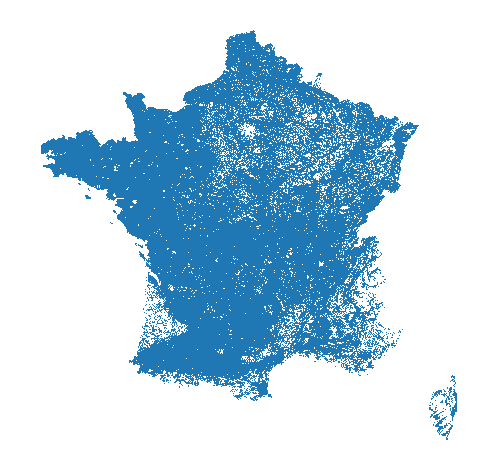

In [6]:
_,ax=plt.subplots()
gdf.plot(ax=ax)
ax.set_axis_off()
plt.tight_layout()
plt.savefig("visualization_ICLR/full_country.png")



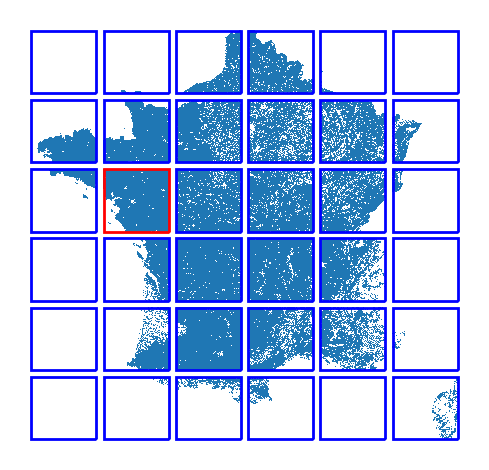

In [7]:
fig, ax = plt.subplots()

gdf[gdf["tile"] != -1].plot(ax=ax)


for (i,tile) in enumerate(tiles):
    color = "blue" if i != 14 else "red"
    plot_polygon(tile,ax=ax,add_points=False, facecolor=(0,0,0,0), color=color, linewidth=2)

plt.grid(False)
ax.set_axis_off()
plt.tight_layout()

plt.savefig("visualization_ICLR/full_country_with_tiles.png")


<Axes: >

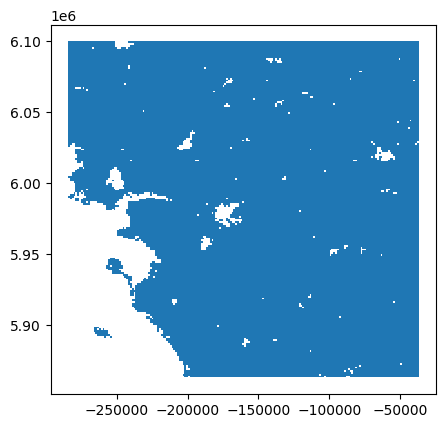

In [8]:
gdf[gdf["tile"] == 14].plot()

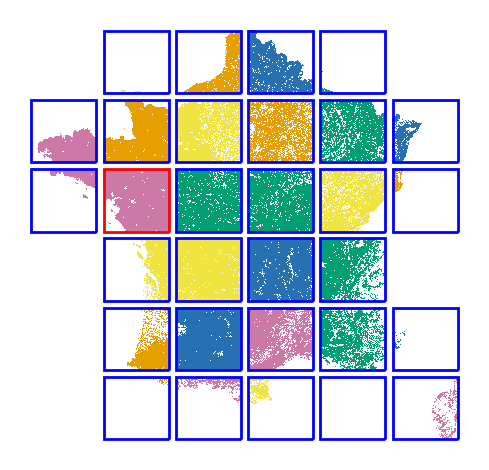

In [9]:
fig, ax = plt.subplots()

curr_gdf = gdf[gdf["tile"] != -1]
point_color = [tile_to_color[i] for i in curr_gdf["tile"]]
curr_gdf.plot(ax=ax,color=point_color)


for (i,tile) in enumerate(tiles):
    if i not in keep_tiles:
        continue
    color = "blue" if i != 14 else "red"
    plot_polygon(tile,ax=ax,add_points=False, facecolor=(0,0,0,0), color=color, linewidth=2)

plt.grid(False)
ax.set_axis_off()
plt.tight_layout()

plt.savefig("visualization_ICLR/full_country_with_tiles_data_colored_by_tilegroup.png")


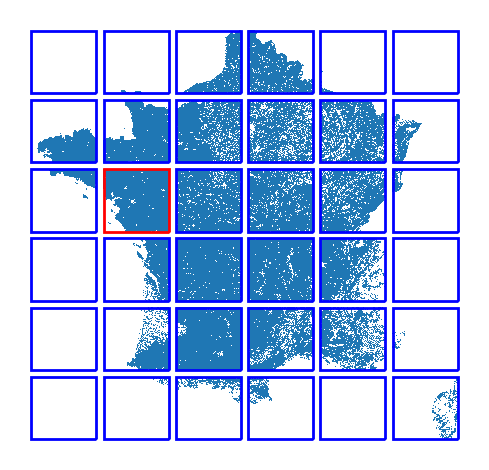

In [10]:
fig, ax = plt.subplots()

tiles = create_tiles(gdf, rows=6, cols=6, buffer_pct=0.1)



gdf[gdf["tile"] != -1].plot(ax=ax)


for (i,tile) in enumerate(tiles):
    color = "blue" if i != 14 else "red"
    plot_polygon(tile,ax=ax,add_points=False, facecolor=(0,0,0,0), color=color, linewidth=2)

plt.grid(False)
ax.set_axis_off()
plt.tight_layout()

plt.savefig("visualization_ICLR/full_country_with_tiles.png")


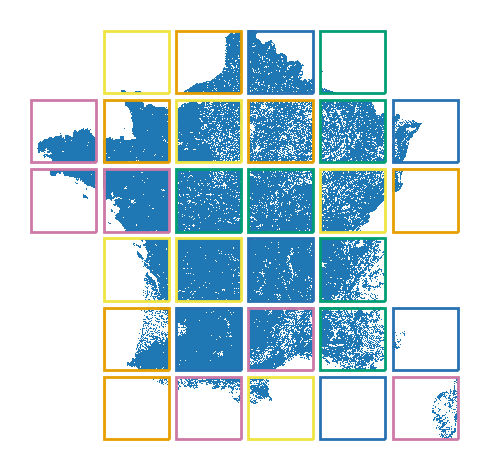

In [11]:
fig, ax = plt.subplots()

gdf[gdf["tile"] != -1].plot(ax=ax, color="tab:blue")


for (i,tile) in enumerate(tiles):
    if i not in reverse_tile_groups:
        continue
    color = tile_to_color[i]
    plot_polygon(tile,ax=ax,add_points=False, facecolor=(0,0,0,0), color=color, linewidth=2)

plt.grid(False)
ax.set_axis_off()
plt.tight_layout()

plt.savefig("visualization_ICLR/full_country_with_tiles_tilegroups_highlighted.png")


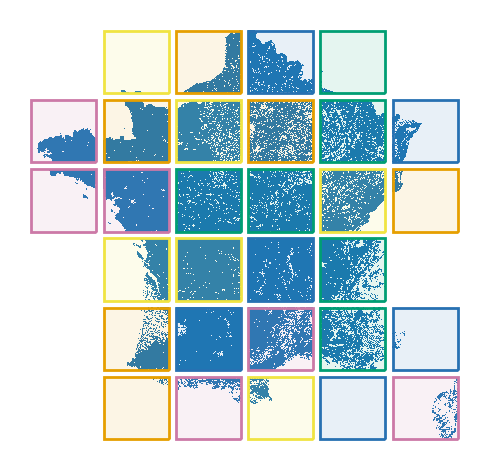

In [12]:
fig, ax = plt.subplots()

gdf[gdf["tile"] != -1].plot(ax=ax, color="tab:blue")


for (i,tile) in enumerate(tiles):
    if i not in reverse_tile_groups:
        continue
    color = tile_to_color[i]
    facecolor = tuple([i / 256 for i in ImageColor.getrgb(tile_to_color[i])] + [0.1])
    plot_polygon(tile,ax=ax,add_points=False, facecolor=facecolor, color=color, linewidth=2)

plt.grid(False)
ax.set_axis_off()
plt.tight_layout()

plt.savefig("visualization_ICLR/full_country_with_tiles_tilegroups_highlighted_facecolor.png")


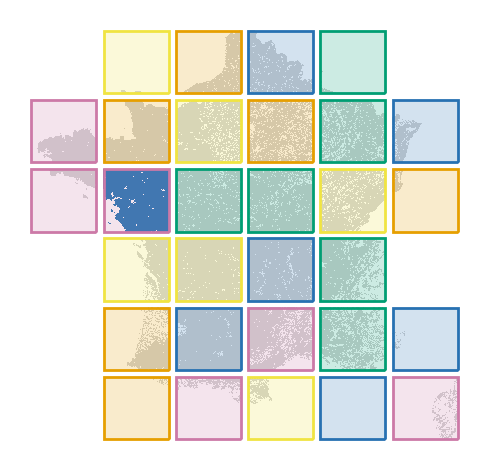

In [13]:
fig, ax = plt.subplots()

cmap = plt.cm.Set1(np.linspace(0, 1, len(groups)))

gdf[~(gdf["tile"].isin([-1,14]))].plot(ax=ax, color="lightgray")
gdf[gdf["tile"] == 14].plot(ax=ax, color="tab:blue")


for (i,tile) in enumerate(tiles):
    if i not in reverse_tile_groups:
        continue
    color = tile_to_color[i]
    facecolor = tuple([i / 256 for i in ImageColor.getrgb(tile_to_color[i])] + [0.2])
    plot_polygon(tile,ax=ax,add_points=False, facecolor=facecolor, color=color, linewidth=2)

plt.grid(False)
ax.set_axis_off()
plt.tight_layout()

plt.savefig("visualization_ICLR/full_country_with_tiles_tilegroups_highlighted_show_specific_tile_facecolor.png")


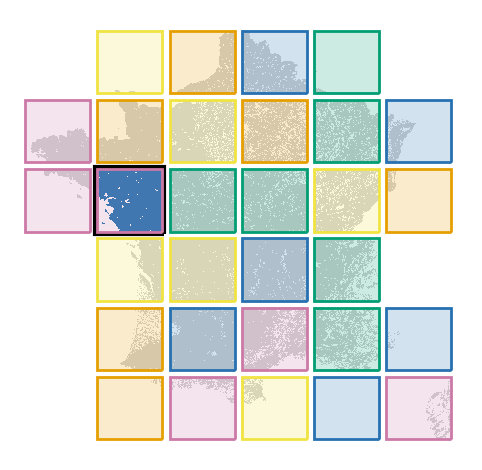

In [14]:
fig, ax = plt.subplots()


gdf[~(gdf["tile"].isin([-1,14]))].plot(ax=ax, color="lightgray")
gdf[gdf["tile"] == 14].plot(ax=ax, color="tab:blue")


minx,miny,maxx,maxy = tiles[14].bounds
buffered_tile = shapely.box(xmin=minx-7500, ymin=miny-7500, xmax=maxx+7500, ymax=maxy+7500)
bminx, bminy, bmaxx, bmaxy = buffered_tile.bounds
ax.set_xlim(min(ax.get_xlim()[0], bminx - 5000), max(ax.get_xlim()[1], bmaxx + 5000))
ax.set_ylim(min(ax.get_ylim()[0], bminy - 5000), max(ax.get_ylim()[1], bmaxy + 5000))
ax.autoscale(False)
plot_polygon(buffered_tile, ax=ax, add_points=False, facecolor="None", color="black", linewidth=3)

bminx, bminy, bmaxx, bmaxy = buffered_tile.bounds
ax.set_xlim(min(ax.get_xlim()[0], bminx - 5000), max(ax.get_xlim()[1], bmaxx + 5000))
ax.set_ylim(min(ax.get_ylim()[0], bminy - 5000), max(ax.get_ylim()[1], bmaxy + 5000))
ax.autoscale(False)

cmap = plt.cm.Set1(np.linspace(0, 1, len(groups)))

for (i, tile) in enumerate(tiles):
    if i not in reverse_tile_groups:
        continue

    color = tile_to_color[i]
    facecolor = tuple([c / 256 for c in ImageColor.getrgb(tile_to_color[i])] + [0.2])
    plot_polygon(tile, ax=ax, add_points=False, facecolor=facecolor, color=color, linewidth=2)

# plot_polygon(buffered_tile, ax=ax, add_points=False, facecolor="None", color="black", linewidth=3)
# color_14 = tile_to_color[14]
# facecolor_14 = tuple([c / 256 for c in ImageColor.getrgb(tile_to_color[14])] + [0.2],zorder=3)
# plot_polygon(tiles[14], ax=ax, add_points=False, facecolor=facecolor_14, color=color_14, linewidth=2)


bminx, bminy, bmaxx, bmaxy = buffered_tile.bounds
ax.set_xlim(min(ax.get_xlim()[0], bminx - 5000), max(ax.get_xlim()[1], bmaxx + 5000))
ax.set_ylim(min(ax.get_ylim()[0], bminy - 5000), max(ax.get_ylim()[1], bmaxy + 5000))
ax.autoscale(False)
plt.grid(False)
ax.set_axis_off()
plt.tight_layout()

bminx, bminy, bmaxx, bmaxy = buffered_tile.bounds
ax.set_xlim(min(ax.get_xlim()[0], bminx - 5000), max(ax.get_xlim()[1], bmaxx + 5000))
ax.set_ylim(min(ax.get_ylim()[0], bminy - 5000), max(ax.get_ylim()[1], bmaxy + 5000))

plt.savefig("visualization_ICLR/full_country_with_tiles_tilegroups_highlighted_show_specific_tile_facecolor.png")

In [15]:
tiles[14].bounds

(-283534.60152673797,
 5863864.813078874,
 -38350.601526737984,
 6099064.813078873)

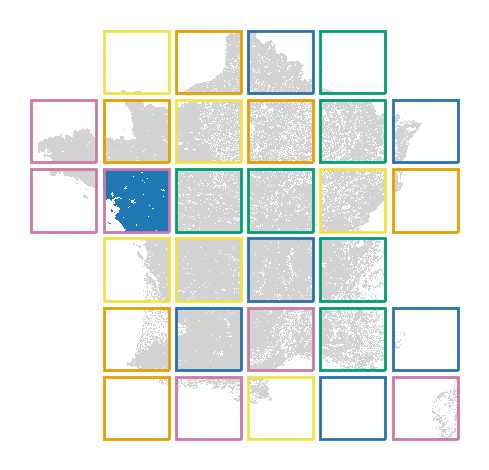

In [16]:
fig, ax = plt.subplots()

cmap = plt.cm.Set1(np.linspace(0, 1, len(groups)))

gdf[~(gdf["tile"].isin([-1,14]))].plot(ax=ax, color="lightgray")
gdf[gdf["tile"] == 14].plot(ax=ax, color="tab:blue")


for (i,tile) in enumerate(tiles):
    if i not in reverse_tile_groups:
        continue
    color = tile_to_color[i]
    plot_polygon(tile,ax=ax,add_points=False, facecolor=(0,0,0,0), color=color, linewidth=2)

plt.grid(False)
ax.set_axis_off()
plt.tight_layout()

plt.savefig("visualization_ICLR/full_country_with_tiles_tilegroups_highlighted_show_specific_tile.png")


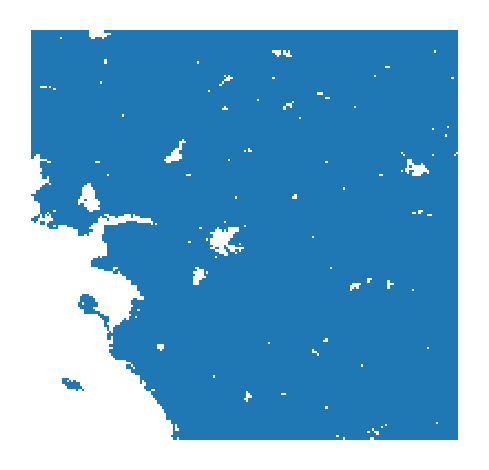

In [17]:
_,ax = plt.subplots()
gdf[gdf["tile"] == 14].plot(ax=ax)
ax.set_axis_off()
plt.tight_layout()
plt.savefig("visualization_ICLR/tile.png")


In [18]:
tile_fourteen_gdf = gdf[(gdf["tile"] == 14) & (gdf["fold"] != -1) ].to_crs("EPSG:3857")

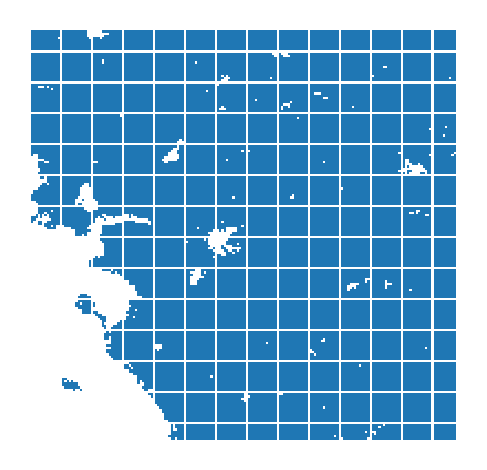

In [19]:
_,ax=plt.subplots()
cmap = plt.get_cmap("tab10", len(tile_fourteen_gdf["fold"].unique()))

fold_to_color = {fold: cmap(i) for i, fold in enumerate(tile_fourteen_gdf["fold"].unique())}

c = tile_fourteen_gdf["fold"].map(fold_to_color)
plt.axis('off')
tile_fourteen_gdf.plot(ax=ax)
ax.set_axis_off()
plt.tight_layout()
plt.savefig("visualization_ICLR/tile_with_cells.png")


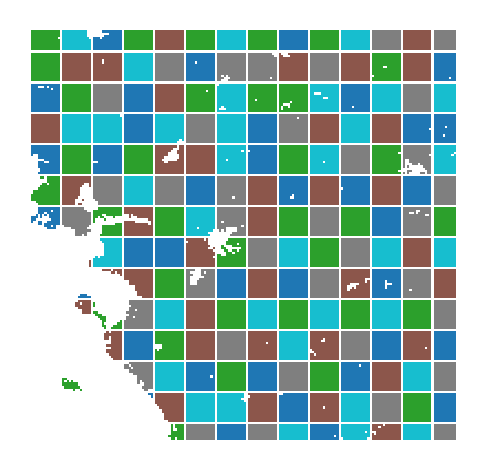

In [20]:
_,ax=plt.subplots()
tile_fourteen_gdf.plot(ax=ax,color=c)
ax.set_axis_off()
plt.tight_layout()
plt.savefig("visualization_ICLR/tile_with_cells_folds.png")

In [21]:
def get_single_cell(gdf, col=0, row=0, cell_size=17920, min_x=-247440, max_y=6105120):
    """
    Returns a single cell from a grid GeoDataFrame.
    
    Parameters:
        gdf: GeoDataFrame containing the grid cells
        col: column index (0 = leftmost)
        row: row index (0 = topmost)
        cell_size: size of each cell in projection units (default 15360)
        min_x: leftmost x coordinate of the grid (default -250000)
        max_y: topmost y coordinate of the grid (default 6100000)
    """
    minx = min_x + col * cell_size
    maxx = minx + cell_size
    maxy = max_y - row * cell_size
    miny = maxy - cell_size

    box = shapely.geometry.box(minx=minx, miny=miny, maxx=maxx, maxy=maxy)
    single_cell = gdf[gdf.intersects(box)]
    
    return single_cell, box

169


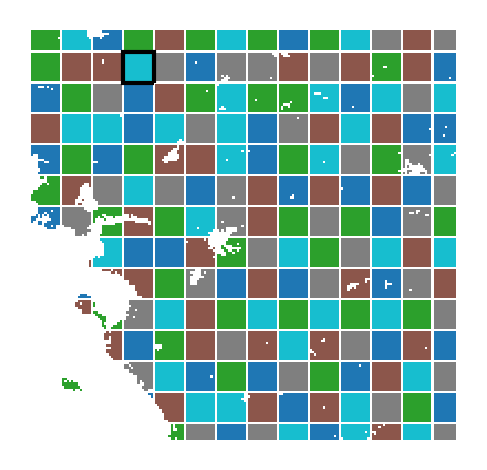

In [22]:
_,ax=plt.subplots()
tile_fourteen_gdf.plot(ax=ax,color=c)
ax.set_axis_off()
plt.tight_layout()
plt.savefig("visualization_ICLR/cells_with_folds.png")

cell, box = get_single_cell(tile_fourteen_gdf, col=1, row=1)

print(len(cell))
tile_fourteen_gdf.plot(ax=ax, color=c)
plot_polygon(box,ax,add_points=False, facecolor=(0,0,0,0), linewidth=3,edgecolor="black")
plt.grid(False)
plt.savefig("visualization_ICLR/tile_with_cells_folds_single_cell_highlighted.png")

ax.set_axis_off()

In [23]:
hedgerows_converted = gpd.GeoDataFrame(geometry=cell["hedgerows"].apply(lambda x: shapely.from_wkt(x)), crs="EPSG:4326").to_crs("EPSG:3857")
cell["hedgerows"] = hedgerows_converted.geometry

/home/nathan/Desktop/BDA_integration/.venv/lib/python3.12/site-packages/geopandas/geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


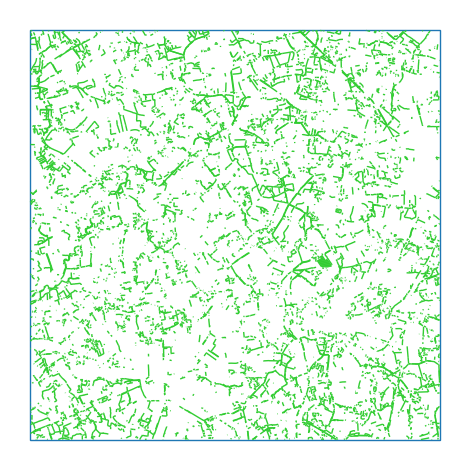

In [24]:
fig,ax = plt.subplots()

for _, row in cell.iterrows():
    geom, hedgerows = row["geometry"], row["hedgerows"]
    gs = gpd.GeoSeries(hedgerows)
    gs.plot(ax=ax, color="limegreen", linewidth=1)

bounds = shapely.box(*cell.total_bounds)
plot_polygon(bounds, add_points=False, facecolor=(0,0,0,0))

plt.grid(False)
ax.set_axis_off()
plt.tight_layout()

plt.savefig("visualization_ICLR/cell.png")


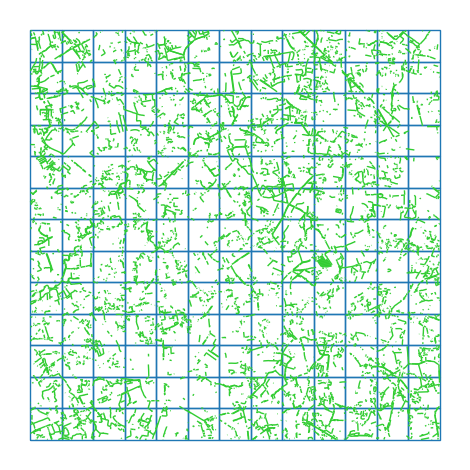

In [25]:
fig,ax = plt.subplots()

for _, row in cell.iterrows():
    geom, hedgerows = row["geometry"], row["hedgerows"]
    plot_polygon(geom, add_points=False, facecolor=(0,0,0,0))
    gs = gpd.GeoSeries(hedgerows)
    gs.plot(ax=ax, color="limegreen", linewidth=1)

plt.grid(False)
ax.set_axis_off()
plt.tight_layout()

plt.savefig("visualization_ICLR/cell_with_patches.png")


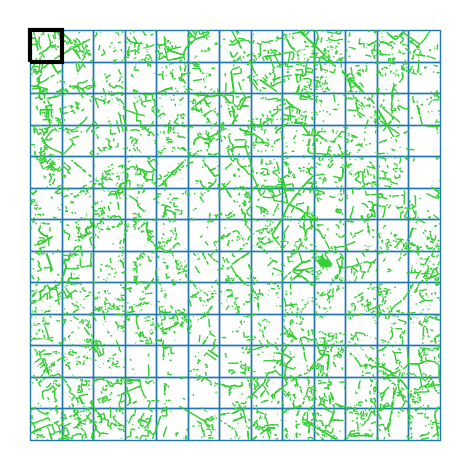

In [26]:
fig,ax = plt.subplots()

for i, row in cell.iterrows():
    geom, hedgerows = row["geometry"], row["hedgerows"]
    edgecolor = ("red" if i == len(cell) else None)
    plot_polygon(geom, add_points=False, edgecolor=edgecolor, facecolor=(0,0,0,0))
    gs = gpd.GeoSeries(hedgerows)
    gs.plot(ax=ax, color="limegreen", linewidth=1)

plot_polygon(cell.geometry.iloc[12], edgecolor="black", add_points=False, linewidth=3, facecolor=(0,0,0,0), zorder=3)

plt.grid(False)
ax.set_axis_off()
plt.tight_layout()

plt.savefig("visualization_ICLR/cell_with_patches_patch_highlighted.png")


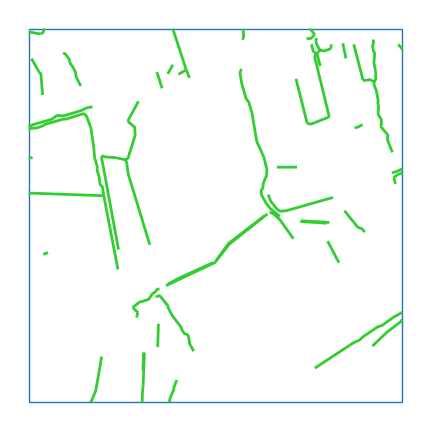

In [27]:
fig,ax = plt.subplots()

geom,hedgerows = cell.geometry.iloc[12], cell["hedgerows"].iloc[12]

plot_polygon(geom, add_points=False, facecolor=(0,0,0,0))
gs = gpd.GeoSeries(hedgerows)
gs.plot(ax=ax, color="limegreen", linewidth=2)
plt.tight_layout()
ax.set_axis_off()
plt.grid(False)
plt.savefig("visualization_ICLR/single_patch.png")


In [28]:
import ee
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import requests
import io
from shapely.ops import transform
import pyproj

def download_s2_patch(
    polygon,
    start_date: str = "2021-04-01",
    end_date: str = "2021-10-01",
    cloud_threshold: int = 20,
    rgb_bands: list = ["B4", "B3", "B2"],
    source_crs: str = "EPSG:3857",
    output_size: int = 128,
    scale: int = 10,
    s2_max: int = 3000,
    gamma: float = 1.4,
    project: str = "hedgementation",
) -> np.ndarray:
    """
    Download a Sentinel-2 RGB patch for a Shapely polygon, output in EPSG:3857.

    Parameters
    ----------
    polygon     : Shapely Polygon/MultiPolygon in `source_crs`
    source_crs  : CRS of the input polygon (default EPSG:3857)
    scale       : Native pixel size in metres for the EPSG:3857 reprojection
    output_size : Width/height of the returned image in pixels

    Returns
    -------
    (H, W, 3) uint8 numpy array ready for plt.imshow()
    """
    ee.Initialize(project=project)

    # --- Reproject polygon to EPSG:4326 (lon/lat) for GEE filtering/clipping ---
    project_to_4326 = pyproj.Transformer.from_crs(
        source_crs, "EPSG:4326", always_xy=True
    ).transform
    polygon_4326 = transform(project_to_4326, polygon)
    ee_region = ee.Geometry(polygon_4326.__geo_interface__)

    # --- Build median composite, then reproject to EPSG:3857 ---
    s2 = (
        ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
        .filterBounds(ee_region)
        .filterDate(start_date, end_date)
        .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", cloud_threshold))
        .select(rgb_bands)
        .median()
        .clip(ee_region)
        .reproject(crs="EPSG:3857", scale=scale)  # <-- reproject before export
    )

    url = s2.getThumbURL({
        "region": ee_region,
        "dimensions": output_size,
        "format": "png",
        "min": 0,
        "max": s2_max,
        "gamma": gamma,
        "crs": "EPSG:3857",   # tell the thumbnail renderer to honour the projection
    })

    response = requests.get(url)
    response.raise_for_status()
    img = Image.open(io.BytesIO(response.content)).convert("RGB")
    return np.array(img)
img = download_s2_patch(geom)

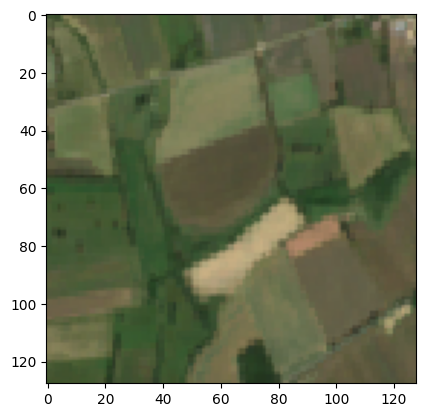

In [29]:
plt.imshow(img)

In [30]:
img.shape


(128, 128, 3)

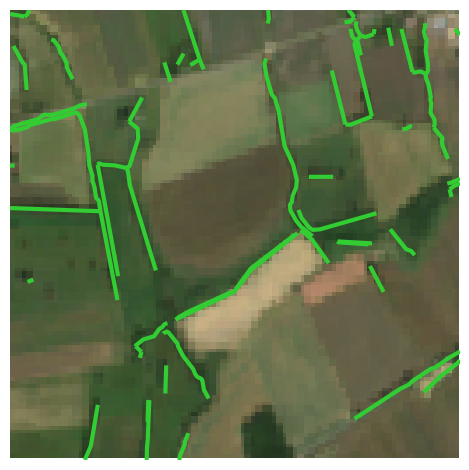

In [31]:
from hedgementation_utils.visualization.visualization_utils import plot_for_rpg_mask_validation, rescale_geometry_to_pixels

img_height, img_width = img.shape[0], img.shape[1]

geom = rescale_geometry_to_pixels(geom, geom.bounds, y_pixels=img_height, x_pixels=img_width)
hedgerows = rescale_geometry_to_pixels(hedgerows, hedgerows.bounds, y_pixels=img_height, x_pixels=img_width)

_, ax = plt.subplots()

ax.imshow(img)
gs = gpd.GeoSeries(hedgerows)
gs.plot(ax=ax, color="limegreen", linewidth=3)

# Clip plotted lines to the image bounds
ax.set_xlim(0, img_width)
ax.set_ylim(img_height, 0)  # Inverted because imshow uses top-left origin

plt.grid(False)
ax.set_axis_off()
plt.tight_layout()

plt.savefig("visualization_ICLR/patch_with_satellite.png")
plt.show()

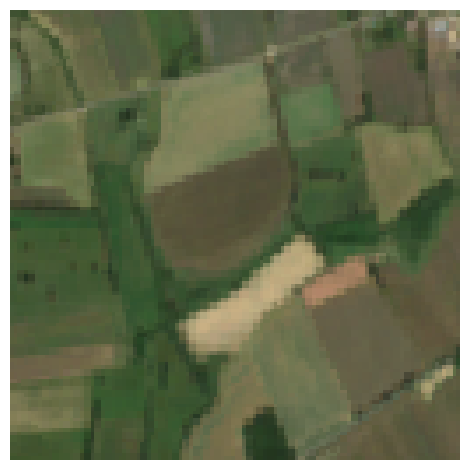

In [32]:
img_height, img_width = img.shape[0], img.shape[1]

_,ax = plt.subplots()

ax.imshow(img)
plt.grid(False)
ax.set_axis_off()
plt.tight_layout()

plt.savefig("visualization_ICLR/patch_satellite_only.png")
plt.show()

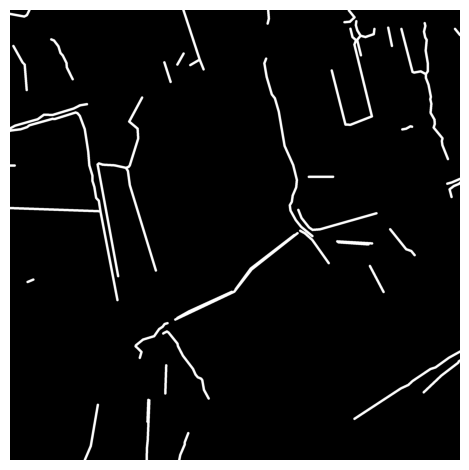

In [33]:
from rasterio.features import rasterize


geom,hedgerows = cell.geometry.iloc[12], cell["hedgerows"].iloc[12]
hedgerows = rescale_geometry_to_pixels(hedgerows.buffer(3.5), hedgerows.bounds, y_pixels=20 * img_height, x_pixels=20 * img_width)

mask = rasterize(
    shapes=[hedgerows],
    out_shape=(20 * img_height,20 * img_height)
)
fig,ax = plt.subplots()
ax.set_axis_off()
plt.tight_layout()
ax.imshow(mask,cmap="gray")

plt.savefig("visualization_ICLR/high_res_hedgerow_raster.png")
plt.show()

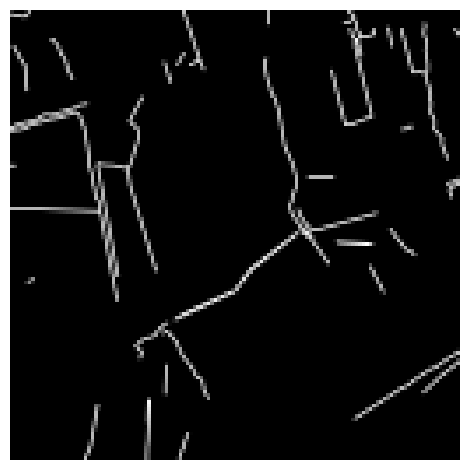

In [34]:
def block_mean(arr, block_size=20):
    h, w = arr.shape
    return (arr.reshape(h // block_size, block_size, w // block_size, block_size)
               .mean(axis=(1, 3)))

downsampled_mask = block_mean(mask)
fig,ax = plt.subplots()
ax.set_axis_off()
plt.tight_layout()
ax.imshow(downsampled_mask,cmap="gray")
plt.savefig("visualization_ICLR/low_res_hedgerow_raster.png")
plt.show()

In [35]:
downsampled_mask.shape

(128, 128)